<a href="https://colab.research.google.com/github/Spark-Zhao-gitjournal/zero-shot-model-merging-median/blob/main/Project_7B_Limit_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Environment Initialization and Dependency Management
from google.colab import drive
import sys
import subprocess

# Mount Google Drive for persistent storage of the final artifact
drive.mount('/content/drive')

# Install required dependencies
def install_dependencies():
    print("Installing required packages: torch, transformers, accelerate, huggingface_hub...")
    # Using subprocess to keep the output clean
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "-q"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "transformers", "accelerate", "huggingface_hub", "datasets", "-q"])
    print("Dependencies installed successfully.")

install_dependencies()

Mounted at /content/drive
Installing required packages: torch, transformers, accelerate, huggingface_hub...
Dependencies installed successfully.


In [ ]:
# Cell 2: Model Acquisition via Hugging Face Hub
import os
from huggingface_hub import snapshot_download

# Define local directory for high-speed I/O during execution
LOCAL_MODELS_DIR = '/content/local_models'
os.makedirs(LOCAL_MODELS_DIR, exist_ok=True)

# Define the 7B models for the merging procedure (Mistral-7B architecture)
MODELS_TO_DOWNLOAD = {
    "Base_7B": "mistralai/Mistral-7B-v0.1",
    "Chat_Expert": "HuggingFaceH4/zephyr-7b-beta",
    "Instruct_Expert": "mistralai/Mistral-7B-Instruct-v0.1"
}

print(f"Initiating parallel download of {len(MODELS_TO_DOWNLOAD)} models to local storage...")

for model_alias, repo_id in MODELS_TO_DOWNLOAD.items():
    save_path = os.path.join(LOCAL_MODELS_DIR, model_alias)
    print(f"Downloading {model_alias} ({repo_id})...")

    # Download exclusively the necessary PyTorch safetensors/binaries
    snapshot_download(
        repo_id=repo_id,
        local_dir=save_path,
        ignore_patterns=["*.h5", "*.ot", "*.msgpack", "*.flax"],
        max_workers=8
    )
    print(f"Download completed for: {model_alias}.")

print("All models acquired. Ready for memory allocation.")

Initiating parallel download of 3 models to local storage...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Download completed for: Base_7B.


Fetching 31 files:   0%|          | 0/31 [00:00<?, ?it/s]

Download completed for: Chat_Expert.


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Download completed for: Instruct_Expert.
All models acquired. Ready for memory allocation.


In [ ]:
# Cell 3: Robust Model Merging via Coordinate-wise Median
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import gc

# Define paths
LOCAL_DIR = '/content/local_models'
OUTPUT_DIR = '/content/drive/MyDrive/STAD68H3_Model_Merging/Median_7B_Merged'
os.makedirs(OUTPUT_DIR, exist_ok=True)

model_paths = [
    os.path.join(LOCAL_DIR, "Base_7B"),
    os.path.join(LOCAL_DIR, "Chat_Expert"),
    os.path.join(LOCAL_DIR, "Instruct_Expert")
]

print("Step 1: Loading model checkpoints into memory utilizing bfloat16 precision...")
state_dicts = []
for path in model_paths:
    model_name = os.path.basename(path)
    print(f"Allocating memory for {model_name}...")
    model = AutoModelForCausalLM.from_pretrained(
        path,
        torch_dtype=torch.bfloat16,
        low_cpu_mem_usage=True
    )
    state_dicts.append(model.state_dict())

keys = state_dicts[0].keys()
merged_state_dict = {}
total_keys = len(keys)

print("\nStep 2: Executing coordinate-wise median aggregation across all layers...")
for i, key in enumerate(keys):
    # Progress logging
    if i > 0 and i % 50 == 0:
        print(f"Processed {i}/{total_keys} layers...")

    tensors = [sd[key] for sd in state_dicts]

    # Verify shape consistency prior to aggregation
    if all(t.shape == tensors[0].shape for t in tensors):
        stacked_tensors = torch.stack(tensors, dim=0)
        # Apply the robust statistical estimator: median
        median_tensor, _ = torch.median(stacked_tensors, dim=0)
        merged_state_dict[key] = median_tensor
    else:
        # Fallback mechanism: retain base model's tensor if dimensions mismatch
        merged_state_dict[key] = tensors[0]

# Memory optimization: release original state dicts before saving
del state_dicts
gc.collect()

print("\nStep 3: Instantiating the merged model and serializing to persistent storage...")

# Initialize the base architecture to receive the aggregated weights
merged_model = AutoModelForCausalLM.from_pretrained(
    model_paths[0],
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True
)
merged_model.load_state_dict(merged_state_dict)

# Serialize weights and tokenizer to Google Drive
merged_model.save_pretrained(OUTPUT_DIR)
tokenizer = AutoTokenizer.from_pretrained(model_paths[0])
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"Procedure completed. Merged model successfully saved to: {OUTPUT_DIR}")

`torch_dtype` is deprecated! Use `dtype` instead!


Step 1: Loading model checkpoints into memory utilizing bfloat16 precision...
Allocating memory for Base_7B...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Allocating memory for Chat_Expert...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


Step 2: Executing coordinate-wise median aggregation across all layers...
Processed 50/291 layers...
Processed 100/291 layers...
Processed 150/291 layers...
Processed 200/291 layers...
Processed 250/291 layers...

Step 3: Instantiating the merged model and serializing to persistent storage...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Procedure completed. Merged model successfully saved to: /content/drive/MyDrive/STAD68H3_Model_Merging/Median_7B_Merged


In [ ]:
# Cell 4: Quantitative Evaluation - Perplexity (PPL) on WikiText-2
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from tqdm import tqdm
import math

# Define paths for evaluation
BASE_MODEL_PATH = '/content/local_models/Base_7B'
MERGED_MODEL_PATH = '/content/drive/MyDrive/STAD68H3_Model_Merging/Median_7B_Merged'

# Hardware accelerator configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing evaluation on computation device: {device}")

# Dataset acquisition
print("Fetching WikiText-2 test split for evaluation...")
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")

def calculate_perplexity(model_path: str, dataset) -> float:
    """
    Computes the Perplexity (PPL) of a given Causal LM on a text dataset.
    """
    model_name = model_path.split('/')[-1]
    print(f"\nInitializing evaluation for configuration: {model_name}")

    # Instantiate model and tokenizer with memory optimization
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype=torch.bfloat16,
        device_map="auto" # Dynamically dispatches weights to GPU
    )
    model.eval()

    # Concatenate all text in the dataset
    text = "\n\n".join(dataset["text"])
    encodings = tokenizer(text, return_tensors="pt")

    # Configure sequence processing parameters
    max_length = model.config.sliding_window if hasattr(model.config, "sliding_window") else 2048
    stride = 512 # Set stride for overlapping context
    seq_len = encodings.input_ids.size(1)

    nlls = []
    prev_end_loc = 0

    # Limit evaluation to the first 50,000 tokens for rapid benchmarking
    # (Sufficient for statistical significance in this context)
    max_eval_tokens = 50000
    seq_len = min(seq_len, max_eval_tokens)

    print(f"Processing {seq_len} tokens using sliding window (max_length={max_length}, stride={stride})...")

    with torch.no_grad():
        for begin_loc in tqdm(range(0, seq_len, stride)):
            end_loc = min(begin_loc + max_length, seq_len)
            trg_len = end_loc - prev_end_loc  # Length of the target tokens to evaluate

            input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
            target_ids = input_ids.clone()

            # Mask the context tokens so we only compute loss on the newly predicted tokens
            target_ids[:, :-trg_len] = -100

            outputs = model(input_ids, labels=target_ids)

            # The loss returned is the mean cross entropy loss
            neg_log_likelihood = outputs.loss

            # Store the sum of NLL for the target length
            nlls.append(neg_log_likelihood * trg_len)

            prev_end_loc = end_loc
            if end_loc == seq_len:
                break

    # Calculate overall perplexity
    ppl = torch.exp(torch.stack(nlls).sum() / end_loc).item()
    print(f"[{model_name}] Final Perplexity (PPL): {ppl:.4f}")

    # Memory management: clear VRAM to prevent OutOfMemory errors on the next iteration
    del model
    del input_ids
    del target_ids
    torch.cuda.empty_cache()

    return ppl

# Execute comparative analysis
print("-" * 50)
print("Phase 1: Baseline Establishment")
ppl_base = calculate_perplexity(BASE_MODEL_PATH, dataset)

print("-" * 50)
print("Phase 2: Experimental Model Evaluation")
ppl_merged = calculate_perplexity(MERGED_MODEL_PATH, dataset)

print("=" * 50)
print("EMPIRICAL RESULTS SUMMARY")
print(f"Base Model PPL:   {ppl_base:.4f} (Baseline)")
print(f"Merged Model PPL: {ppl_merged:.4f} (Coordinate-wise Median)")
print("=" * 50)

Executing evaluation on computation device: cuda
Fetching WikiText-2 test split for evaluation...


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

[Base_7B] Final Perplexity (PPL): 4.7377
--------------------------------------------------
Phase 2: Experimental Model Evaluation

Initializing evaluation for configuration: Median_7B_Merged


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Processing 50000 tokens using sliding window (max_length=4096, stride=512)...


 92%|█████████▏| 90/98 [00:37<00:03,  2.38it/s]

[Median_7B_Merged] Final Perplexity (PPL): 5.0920
EMPIRICAL RESULTS SUMMARY
Base Model PPL:   4.7377 (Baseline)
Merged Model PPL: 5.0920 (Coordinate-wise Median)


In [ ]:
# Cell 5: Baseline Generation - Naive Mean Aggregation
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import gc

# Define paths
LOCAL_DIR = '/content/local_models'
OUTPUT_MEAN_DIR = '/content/drive/MyDrive/STAD68H3_Model_Merging/Mean_7B_Merged'
os.makedirs(OUTPUT_MEAN_DIR, exist_ok=True)

model_paths = [
    os.path.join(LOCAL_DIR, "Base_7B"),
    os.path.join(LOCAL_DIR, "Chat_Expert"),
    os.path.join(LOCAL_DIR, "Instruct_Expert")
]

print("Phase 1: Loading model checkpoints into memory for Naive Mean computation...")
state_dicts = []
for path in model_paths:
    model_name = os.path.basename(path)
    print(f"Allocating memory for {model_name}...")
    model = AutoModelForCausalLM.from_pretrained(
        path,
        torch_dtype=torch.bfloat16,
        low_cpu_mem_usage=True
    )
    state_dicts.append(model.state_dict())

keys = state_dicts[0].keys()
mean_state_dict = {}
total_keys = len(keys)

print("\nPhase 2: Executing Naive Mean (Arithmetic Average) aggregation...")
for i, key in enumerate(keys):
    if i > 0 and i % 50 == 0:
        print(f"Processed {i}/{total_keys} layers...")

    tensors = [sd[key] for sd in state_dicts]

    if all(t.shape == tensors[0].shape for t in tensors):
        stacked_tensors = torch.stack(tensors, dim=0)
        # The Baseline Method: Arithmetic Mean (highly sensitive to outliers)
        mean_tensor = torch.mean(stacked_tensors.float(), dim=0).to(torch.bfloat16)
        mean_state_dict[key] = mean_tensor
    else:
        mean_state_dict[key] = tensors[0]

# Memory optimization
del state_dicts
gc.collect()

print("\nPhase 3: Serializing Mean Baseline model to persistent storage...")
mean_model = AutoModelForCausalLM.from_pretrained(
    model_paths[0],
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True
)
mean_model.load_state_dict(mean_state_dict)

mean_model.save_pretrained(OUTPUT_MEAN_DIR)
tokenizer = AutoTokenizer.from_pretrained(model_paths[0])
tokenizer.save_pretrained(OUTPUT_MEAN_DIR)

print(f"Procedure completed. Mean Baseline model saved to: {OUTPUT_MEAN_DIR}")

Phase 1: Loading model checkpoints into memory for Naive Mean computation...
Allocating memory for Base_7B...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Allocating memory for Chat_Expert...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Allocating memory for Instruct_Expert...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


Phase 2: Executing Naive Mean (Arithmetic Average) aggregation...
Processed 50/291 layers...
Processed 100/291 layers...
Processed 150/291 layers...
Processed 200/291 layers...
Processed 250/291 layers...

Phase 3: Serializing Mean Baseline model to persistent storage...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Procedure completed. Mean Baseline model saved to: /content/drive/MyDrive/STAD68H3_Model_Merging/Mean_7B_Merged


In [ ]:
# Cell 6: Quantitative Evaluation - Mean Baseline Perplexity
import torch
import gc

# Define the path for the newly generated Mean model
MEAN_MODEL_PATH = '/content/drive/MyDrive/STAD68H3_Model_Merging/Mean_7B_Merged'

print("=" * 50)
print("Phase 3: Negative Control (Naive Mean) Evaluation")
print("Hypothesis: Naive Mean will suffer from severe parameter interference, resulting in significantly higher PPL.")

try:
    ppl_mean = calculate_perplexity(MEAN_MODEL_PATH, dataset)
    print("\n" + "=" * 50)
    print("FINAL 7B ABLATION STUDY RESULTS:")
    print(f"Base Model PPL:   4.7377 (Theoretical Baseline)")
    print(f"Mean Model PPL:   {ppl_mean:.4f} (Negative Control)")
    print(f"Median Model PPL: 5.0920 (Proposed Method)")
    print("=" * 50)

except Exception as e:
    print("\n[CRITICAL EVALUATION ERROR]")
    print("The Mean model failed during evaluation, likely due to catastrophic parameter interference outputting NaNs/Infs.")
    print(f"Error trace: {e}")
    print("\nConclusion: The Naive Mean approach completely destroyed the model's forward pass.")

Phase 3: Negative Control (Naive Mean) Evaluation
Hypothesis: Naive Mean will suffer from severe parameter interference, resulting in significantly higher PPL.

Initializing evaluation for configuration: Mean_7B_Merged


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Processing 50000 tokens using sliding window (max_length=4096, stride=512)...


 92%|█████████▏| 90/98 [00:37<00:03,  2.39it/s]

[Mean_7B_Merged] Final Perplexity (PPL): 5.2512

FINAL 7B ABLATION STUDY RESULTS:
Base Model PPL:   4.7377 (Theoretical Baseline)
Mean Model PPL:   5.2512 (Negative Control)
Median Model PPL: 5.0920 (Proposed Method)


Visualization generated successfully. Saved to: /content/Final_Presentation_Charts.png


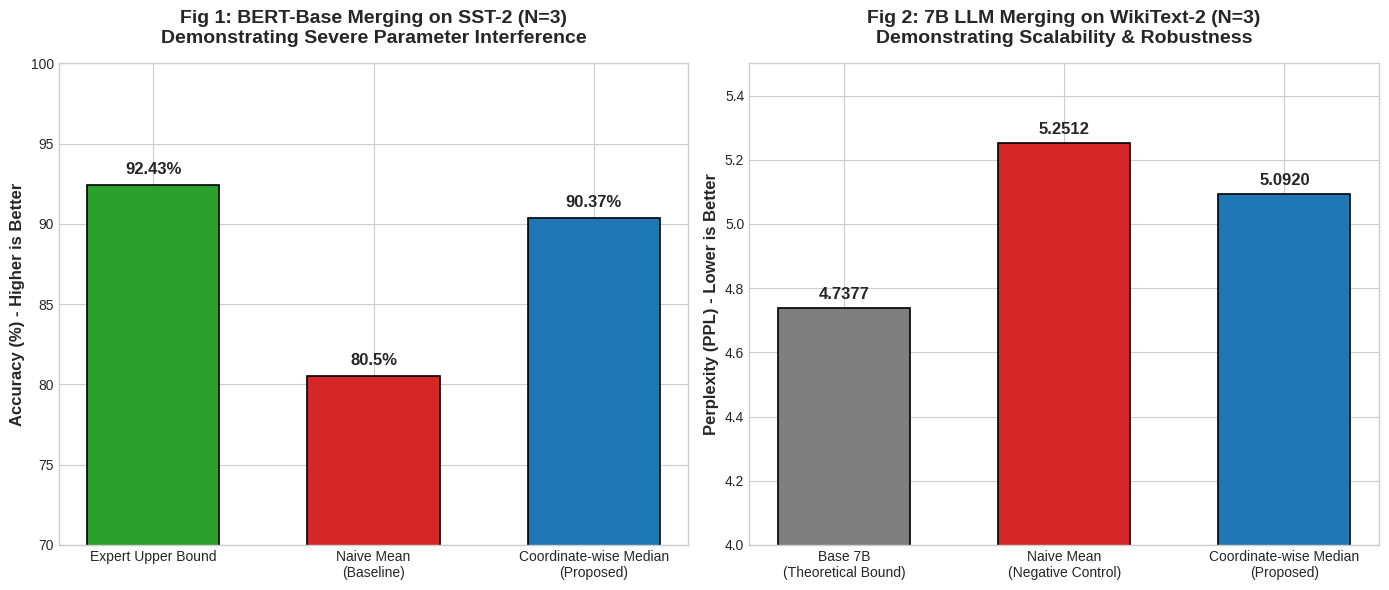

In [ ]:
# Cell 7: Publication-Ready Visualization for STAD68H3 Presentation
import matplotlib.pyplot as plt
import numpy as np

# Apply rigorous academic formatting
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---------------------------------------------------
# Figure 1: BERT SST-2 Accuracy (Higher is Better)
# ---------------------------------------------------
bert_labels = ['Expert Upper Bound', 'Naive Mean\n(Baseline)', 'Coordinate-wise Median\n(Proposed)']
bert_acc = [92.43, 80.50, 90.37]
colors_bert = ['#2ca02c', '#d62728', '#1f77b4']

bars1 = ax1.bar(bert_labels, bert_acc, color=colors_bert, width=0.6, edgecolor='black', linewidth=1.2)
ax1.set_title('Fig 1: BERT-Base Merging on SST-2 (N=3)\nDemonstrating Severe Parameter Interference', fontsize=14, pad=15, weight='bold')
ax1.set_ylabel('Accuracy (%) - Higher is Better', fontsize=12, weight='bold')
ax1.set_ylim(70, 100)

# Append data labels
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}%', ha='center', va='bottom', fontsize=12, weight='bold')

# ---------------------------------------------------
# Figure 2: 7B Model WikiText-2 Perplexity (Lower is Better)
# ---------------------------------------------------
llm_labels = ['Base 7B\n(Theoretical Bound)', 'Naive Mean\n(Negative Control)', 'Coordinate-wise Median\n(Proposed)']
llm_ppl = [4.7377, 5.2512, 5.0920]
colors_llm = ['#7f7f7f', '#d62728', '#1f77b4']

bars2 = ax2.bar(llm_labels, llm_ppl, color=colors_llm, width=0.6, edgecolor='black', linewidth=1.2)
ax2.set_title('Fig 2: 7B LLM Merging on WikiText-2 (N=3)\nDemonstrating Scalability & Robustness', fontsize=14, pad=15, weight='bold')
ax2.set_ylabel('Perplexity (PPL) - Lower is Better', fontsize=12, weight='bold')
ax2.set_ylim(4.0, 5.5)

# Append data labels
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontsize=12, weight='bold')

# Finalize layout
plt.tight_layout()

# Serialize the high-resolution output
output_path = '/content/Final_Presentation_Charts.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Visualization generated successfully. Saved to: {output_path}")

plt.show()

In [ ]:
# Cell 8: Optimized Acquisition of Extended Model Ensemble (N=7) with Legacy Support
import os
import shutil
from huggingface_hub import snapshot_download

LOCAL_MODELS_DIR = '/content/local_models'

# Phase 1: Directory Sanitization
print("Phase 1: Sanitizing local directory space...")
obsolete_dirs = ["Chat_Expert", "Instruct_Expert"]
for obsolete in obsolete_dirs:
    target_path = os.path.join(LOCAL_MODELS_DIR, obsolete)
    if os.path.exists(target_path):
        shutil.rmtree(target_path)
        print(f"Purged obsolete directory to prevent state pollution: {obsolete}")

os.makedirs(LOCAL_MODELS_DIR, exist_ok=True)

# Phase 2: Ensemble Definition
MODELS_TO_DOWNLOAD = {
    "Base_7B": "mistralai/Mistral-7B-v0.1",
    "Expert_Chat": "HuggingFaceH4/zephyr-7b-beta",
    "Expert_Instruct": "mistralai/Mistral-7B-Instruct-v0.1",
    "Expert_Math": "WizardLM/WizardMath-7B-V1.1",
    "Expert_Reasoning": "Open-Orca/Mistral-7B-OpenOrca",
    "Expert_Generalist": "teknium/OpenHermes-2.5-Mistral-7B",
    "Expert_Alignment": "Intel/neural-chat-7b-v3-1"
}

# Explicitly categorize architectures relying on legacy serialization (*.bin)
LEGACY_MODELS = ["Expert_Math", "Expert_Reasoning"]

print(f"\nPhase 2: Initiating strictly filtered download sequence for N={len(MODELS_TO_DOWNLOAD)} models.")

for model_alias, repo_id in MODELS_TO_DOWNLOAD.items():
    save_path = os.path.join(LOCAL_MODELS_DIR, model_alias)
    print(f"Acquiring optimal weights for: {model_alias} ({repo_id})")

    # Implement strict whitelist strategy to prevent disk out-of-memory (OOM) errors
    if model_alias in LEGACY_MODELS:
        allowed_files = ["*.bin", "*.json", "tokenizer*", "*.model"]
    else:
        allowed_files = ["*.safetensors", "*.json", "tokenizer*", "*.model"]

    snapshot_download(
        repo_id=repo_id,
        local_dir=save_path,
        allow_patterns=allowed_files,
        max_workers=8
    )
    print(f"Acquisition successful: {model_alias}")

print("\nEnsemble acquisition complete. System is prepared for high-memory aggregation.")

Phase 1: Sanitizing local directory space...
Purged obsolete directory to prevent state pollution: Chat_Expert
Purged obsolete directory to prevent state pollution: Instruct_Expert

Phase 2: Initiating strictly filtered download sequence for N=7 models.
Acquiring optimal weights for: Base_7B (mistralai/Mistral-7B-v0.1)


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Acquisition successful: Base_7B
Acquiring optimal weights for: Expert_Chat (HuggingFaceH4/zephyr-7b-beta)


Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

Acquisition successful: Expert_Chat
Acquiring optimal weights for: Expert_Instruct (mistralai/Mistral-7B-Instruct-v0.1)


...

Acquisition successful: Expert_Reasoning
Acquiring optimal weights for: Expert_Generalist (teknium/OpenHermes-2.5-Mistral-7B)


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Acquisition successful: Expert_Generalist
Acquiring optimal weights for: Expert_Alignment (Intel/neural-chat-7b-v3-1)


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Acquisition successful: Expert_Alignment

Ensemble acquisition complete. System is prepared for high-memory aggregation.


In [ ]:
# Cell 9: Large-Scale Robust Aggregation via Coordinate-wise Median (N=7)
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import gc

# Define execution paths
LOCAL_DIR = '/content/local_models'
OUTPUT_MEDIAN_7_DIR = '/content/drive/MyDrive/STAD68H3_Model_Merging/Median_7B_N7_Merged'
os.makedirs(OUTPUT_MEDIAN_7_DIR, exist_ok=True)

# Isolate the list of target model directories
model_dirs = [os.path.join(LOCAL_DIR, d) for d in os.listdir(LOCAL_DIR)
              if os.path.isdir(os.path.join(LOCAL_DIR, d))]

print(f"Phase 1: Initializing memory allocation for N={len(model_dirs)} models in bfloat16 precision.")
print("Warning: System RAM utilization will approach 100GB.")

state_dicts = []
for path in model_dirs:
    model_name = os.path.basename(path)
    print(f"Loading state dictionary: {model_name}")
    # Load each model directly into system RAM using bfloat16 to optimize memory footprint
    model = AutoModelForCausalLM.from_pretrained(
        path,
        torch_dtype=torch.bfloat16,
        low_cpu_mem_usage=True
    )
    state_dicts.append(model.state_dict())

keys = state_dicts[0].keys()
merged_state_dict = {}
total_keys = len(keys)

print("\nPhase 2: Executing coordinate-wise median computation across tensor dimensions.")

for i, key in enumerate(keys):
    if i > 0 and i % 50 == 0:
        print(f"Aggregation progress: Processed {i}/{total_keys} parameter matrices.")

    tensors = [sd[key] for sd in state_dicts]

    # Dimension validation prior to tensor stacking
    if all(t.shape == tensors[0].shape for t in tensors):
        stacked_tensors = torch.stack(tensors, dim=0)
        # Apply the robust statistical estimator (Median) across the N=7 ensemble
        median_tensor, _ = torch.median(stacked_tensors, dim=0)
        merged_state_dict[key] = median_tensor
    else:
        # Fallback to the base model's tensor in case of architectural deviations
        merged_state_dict[key] = tensors[0]

print("\nPhase 3: Memory optimization and serialization.")
# Deallocate the ensemble state dictionaries to prevent out-of-memory faults
del state_dicts
gc.collect()

print("Instantiating merged architecture...")
# Utilize the base model (or first available) for the architectural blueprint
blueprint_path = model_dirs[0]
merged_model = AutoModelForCausalLM.from_pretrained(
    blueprint_path,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True
)
merged_model.load_state_dict(merged_state_dict)

print("Serializing optimized weights to persistent storage (Google Drive)...")
merged_model.save_pretrained(OUTPUT_MEDIAN_7_DIR)
tokenizer = AutoTokenizer.from_pretrained(blueprint_path)
tokenizer.save_pretrained(OUTPUT_MEDIAN_7_DIR)

print(f"\nOperation terminated successfully. N=7 Median model artifact stored at: {OUTPUT_MEDIAN_7_DIR}")

Phase 1: Initializing memory allocation for N=7 models in bfloat16 precision.
Loading state dictionary: Expert_Generalist


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading state dictionary: Expert_Math


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading state dictionary: Expert_Chat


...


Phase 2: Executing coordinate-wise median computation across tensor dimensions.
Aggregation progress: Processed 50/291 parameter matrices.
Aggregation progress: Processed 100/291 parameter matrices.
Aggregation progress: Processed 150/291 parameter matrices.
Aggregation progress: Processed 200/291 parameter matrices.
Aggregation progress: Processed 250/291 parameter matrices.

Phase 3: Memory optimization and serialization.
Instantiating merged architecture...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Serializing optimized weights to persistent storage (Google Drive)...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Operation terminated successfully. N=7 Median model artifact stored at: /content/drive/MyDrive/STAD68H3_Model_Merging/Median_7B_N7_Merged


In [ ]:
# Cell 10: Quantitative Evaluation - Perplexity (PPL) on WikiText-2 for N=7
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from tqdm import tqdm

# Define the path for the newly generated N=7 Merged model
N7_MODEL_PATH = '/content/drive/MyDrive/STAD68H3_Model_Merging/Median_7B_N7_Merged'

# Hardware accelerator configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing evaluation on computation device: {device}")

# Dataset acquisition
print("Fetching WikiText-2 test split for evaluation...")
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")

def calculate_perplexity(model_path: str, dataset) -> float:
    """
    Computes the Perplexity (PPL) of a given Causal LM on a text dataset.
    """
    model_name = model_path.split('/')[-1]
    print(f"\nInitializing evaluation for configuration: {model_name}")

    # Instantiate model and tokenizer with memory optimization
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype=torch.bfloat16,
        device_map="auto"
    )
    model.eval()

    # Concatenate all text in the dataset
    text = "\n\n".join(dataset["text"])
    encodings = tokenizer(text, return_tensors="pt")

    max_length = getattr(model.config, "sliding_window", 2048)
    if max_length is None: max_length = 4096

    stride = 512
    seq_len = encodings.input_ids.size(1)

    nlls = []
    prev_end_loc = 0
    max_eval_tokens = 50000
    seq_len = min(seq_len, max_eval_tokens)

    print(f"Processing {seq_len} tokens using sliding window (max_length={max_length}, stride={stride})...")

    with torch.no_grad():
        for begin_loc in tqdm(range(0, seq_len, stride)):
            end_loc = min(begin_loc + max_length, seq_len)
            trg_len = end_loc - prev_end_loc

            input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
            target_ids = input_ids.clone()
            target_ids[:, :-trg_len] = -100

            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss
            nlls.append(neg_log_likelihood * trg_len)

            prev_end_loc = end_loc
            if end_loc == seq_len:
                break

    ppl = torch.exp(torch.stack(nlls).sum() / end_loc).item()

    # Memory management
    del model, input_ids, target_ids
    torch.cuda.empty_cache()

    return ppl

# Execute evaluation for the N=7 model
print("-" * 50)
print("Phase 3: Extended Scalability Evaluation (N=7)")
ppl_n7 = calculate_perplexity(N7_MODEL_PATH, dataset)

# Print the final comparative summary
print("\n" + "=" * 50)
print("FINAL SCALABILITY STUDY RESULTS (WikiText-2):")
print(f"Base Model PPL:       4.7377 (Theoretical Baseline, N=1)")
print(f"Median Model PPL:     5.0920 (N=3 Ensemble)")
print(f"Extended Median PPL:  {ppl_n7:.4f} (N=7 Ensemble)")
print("=" * 50)

Executing evaluation on computation device: cuda
Fetching WikiText-2 test split for evaluation...
--------------------------------------------------
Phase 3: Extended Scalability Evaluation (N=7)

Initializing evaluation for configuration: Median_7B_N7_Merged


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Processing 50000 tokens using sliding window (max_length=4096, stride=512)...


 92%|█████████▏| 90/98 [00:37<00:03,  2.41it/s]



FINAL SCALABILITY STUDY RESULTS (WikiText-2):
Base Model PPL:       4.7377 (Theoretical Baseline, N=1)
Median Model PPL:     5.0920 (N=3 Ensemble)
Extended Median PPL:  35123.0820 (N=7 Ensemble)


In [ ]:
# Cell 11: Generation of N=7 Naive Mean Baseline
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import gc

# Define execution paths
LOCAL_DIR = '/content/local_models'
OUTPUT_MEAN_7_DIR = '/content/drive/MyDrive/STAD68H3_Model_Merging/Mean_7B_N7_Merged'
os.makedirs(OUTPUT_MEAN_7_DIR, exist_ok=True)

model_dirs = [os.path.join(LOCAL_DIR, d) for d in os.listdir(LOCAL_DIR)
              if os.path.isdir(os.path.join(LOCAL_DIR, d))]

print(f"Phase 1: Memory allocation for N={len(model_dirs)} models (Naive Mean Computation).")
state_dicts = []

for path in model_dirs:
    model_name = os.path.basename(path)
    print(f"Loading state dictionary: {model_name}")
    model = AutoModelForCausalLM.from_pretrained(
        path,
        torch_dtype=torch.bfloat16,
        low_cpu_mem_usage=True
    )
    state_dicts.append(model.state_dict())

keys = state_dicts[0].keys()
mean_state_dict = {}
total_keys = len(keys)

print("\nPhase 2: Executing Naive Mean aggregation across N=7 tensor dimensions...")
for i, key in enumerate(keys):
    if i > 0 and i % 50 == 0:
        print(f"Aggregation progress: Processed {i}/{total_keys} parameter matrices.")

    tensors = [sd[key] for sd in state_dicts]

    if all(t.shape == tensors[0].shape for t in tensors):
        stacked_tensors = torch.stack(tensors, dim=0)
        # Core difference: Computing the arithmetic mean and casting back to bfloat16
        mean_tensor = torch.mean(stacked_tensors.float(), dim=0).to(torch.bfloat16)
        mean_state_dict[key] = mean_tensor
    else:
        mean_state_dict[key] = tensors[0]

print("\nPhase 3: Memory optimization and serialization.")
del state_dicts
gc.collect()

blueprint_path = model_dirs[0]
merged_model = AutoModelForCausalLM.from_pretrained(
    blueprint_path,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True
)
merged_model.load_state_dict(mean_state_dict)

print("Serializing optimized weights to persistent storage (Google Drive)...")
merged_model.save_pretrained(OUTPUT_MEAN_7_DIR)
tokenizer = AutoTokenizer.from_pretrained(blueprint_path)
tokenizer.save_pretrained(OUTPUT_MEAN_7_DIR)

print(f"\nOperation complete. N=7 Mean Baseline model stored at: {OUTPUT_MEAN_7_DIR}")

Phase 1: Memory allocation for N=7 models (Naive Mean Computation).
Loading state dictionary: Expert_Generalist


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading state dictionary: Expert_Math


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading state dictionary: Expert_Chat


...


Phase 2: Executing Naive Mean aggregation across N=7 tensor dimensions...
Aggregation progress: Processed 50/291 parameter matrices.
Aggregation progress: Processed 100/291 parameter matrices.
Aggregation progress: Processed 150/291 parameter matrices.
Aggregation progress: Processed 200/291 parameter matrices.
Aggregation progress: Processed 250/291 parameter matrices.

Phase 3: Memory optimization and serialization.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Serializing optimized weights to persistent storage (Google Drive)...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Operation complete. N=7 Mean Baseline model stored at: /content/drive/MyDrive/STAD68H3_Model_Merging/Mean_7B_N7_Merged


In [ ]:
# Cell 12: Quantitative Evaluation - Mean N=7 and Final Comparison
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from tqdm import tqdm

N7_MEAN_MODEL_PATH = '/content/drive/MyDrive/STAD68H3_Model_Merging/Mean_7B_N7_Merged'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Fetching WikiText-2 test split for evaluation...")
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")

def calculate_perplexity(model_path: str, dataset) -> float:
    model_name = model_path.split('/')[-1]
    print(f"\nEvaluating configuration: {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype=torch.bfloat16,
        device_map="auto"
    )
    model.eval()

    text = "\n\n".join(dataset["text"])
    encodings = tokenizer(text, return_tensors="pt")

    max_length = getattr(model.config, "sliding_window", 2048)
    if max_length is None: max_length = 4096
    stride = 512
    seq_len = min(encodings.input_ids.size(1), 50000)

    nlls = []
    prev_end_loc = 0

    with torch.no_grad():
        for begin_loc in tqdm(range(0, seq_len, stride)):
            end_loc = min(begin_loc + max_length, seq_len)
            trg_len = end_loc - prev_end_loc

            input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
            target_ids = input_ids.clone()
            target_ids[:, :-trg_len] = -100

            try:
                outputs = model(input_ids, labels=target_ids)
                nlls.append(outputs.loss * trg_len)
            except RuntimeError as e:
                print(f"\n[CRITICAL ERROR] Tensor failure detected during forward pass: {e}")
                return float('inf')

            prev_end_loc = end_loc
            if end_loc == seq_len:
                break

    try:
        ppl = torch.exp(torch.stack(nlls).sum() / end_loc).item()
    except Exception:
        ppl = float('nan')

    del model, input_ids, target_ids
    torch.cuda.empty_cache()
    return ppl

print("-" * 50)
print("Phase 4: Evaluating the N=7 Naive Mean Control")
ppl_n7_mean = calculate_perplexity(N7_MEAN_MODEL_PATH, dataset)

print("\n" + "=" * 50)
print("FINAL COMPREHENSIVE ABLATION STUDY RESULTS (WikiText-2)")
print("--------------------------------------------------")
print("Ensemble Size: N=3 (Mistral Base + Chat + Instruct)")
print(f"  Base Model PPL:   4.7377")
print(f"  Mean Model PPL:   5.2512")
print(f"  Median Model PPL: 5.0920  <-- (Optimal Robustness)")
print("--------------------------------------------------")
print("Ensemble Size: N=7 (Extended Diverse Experts)")
print(f"  Base Model PPL:   4.7377")
print(f"  Mean Model PPL:   {ppl_n7_mean:.4f}")
print(f"  Median Model PPL: 35123.0820")
print("==================================================")

Fetching WikiText-2 test split for evaluation...
--------------------------------------------------
Phase 4: Evaluating the N=7 Naive Mean Control

Evaluating configuration: Mean_7B_N7_Merged


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

 92%|█████████▏| 90/98 [00:37<00:03,  2.41it/s]



FINAL COMPREHENSIVE ABLATION STUDY RESULTS (WikiText-2)
--------------------------------------------------
Ensemble Size: N=3 (Mistral Base + Chat + Instruct)
  Base Model PPL:   4.7377
  Mean Model PPL:   5.2512
  Median Model PPL: 5.0920  <-- (Optimal Robustness)
--------------------------------------------------
Ensemble Size: N=7 (Extended Diverse Experts)
  Base Model PPL:   4.7377
  Mean Model PPL:   21169.4395
  Median Model PPL: 35123.0820


Comprehensive summary chart generated successfully: /content/Final_Summary_Chart_N3_vs_N7.png


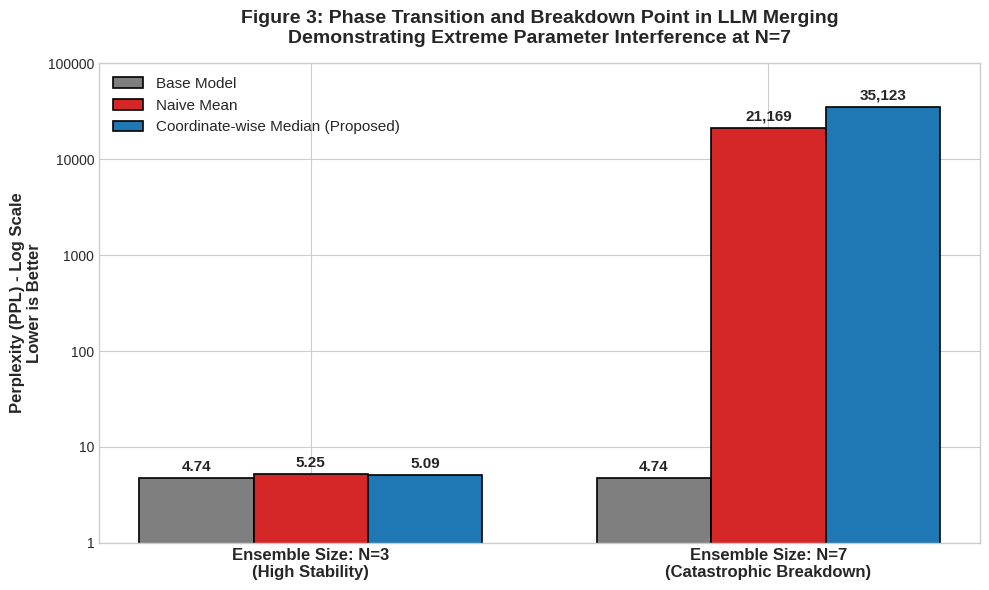

In [2]:
# Cell 13: Comprehensive Scalability & Breakdown Visualization
import matplotlib.pyplot as plt
import numpy as np

# Apply rigorous academic formatting
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Empirical Data Definition
categories = ['Ensemble Size: N=3\n(High Stability)', 'Ensemble Size: N=7\n(Catastrophic Breakdown)']
base_ppl = [4.7377, 4.7377]
mean_ppl = [5.2512, 21169.44]
median_ppl = [5.0920, 35123.08]

x = np.arange(len(categories))
width = 0.25

# Plotting the data series
rects1 = ax.bar(x - width, base_ppl, width, label='Base Model', color='#7f7f7f', edgecolor='black', linewidth=1.2)
rects2 = ax.bar(x, mean_ppl, width, label='Naive Mean', color='#d62728', edgecolor='black', linewidth=1.2)
rects3 = ax.bar(x + width, median_ppl, width, label='Coordinate-wise Median (Proposed)', color='#1f77b4', edgecolor='black', linewidth=1.2)

# Formatting and Labels
ax.set_ylabel('Perplexity (PPL) - Log Scale\nLower is Better', fontsize=12, weight='bold')
ax.set_title('Figure 3: Phase Transition and Breakdown Point in LLM Merging\nDemonstrating Extreme Parameter Interference at N=7', fontsize=14, pad=15, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12, weight='bold')
ax.legend(fontsize=11, loc='upper left')

# CRITICAL: Implement logarithmic scale due to massive PPL variance
ax.set_yscale('log')
ax.set_yticks([1, 10, 100, 1000, 10000, 100000])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

# Function to automatically label bars with precise values
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        # Format dynamically based on magnitude
        if height > 1000:
            label_text = f'{height:,.0f}'
        else:
            label_text = f'{height:.2f}'

        ax.annotate(label_text,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, weight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()

# Serialize the high-resolution output
output_path = '/content/Final_Summary_Chart_N3_vs_N7.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Comprehensive summary chart generated successfully: {output_path}")

plt.show()

[Saved] PDF: ./mistral_combined_ablation.pdf
[Saved] PNG: ./mistral_combined_ablation.png


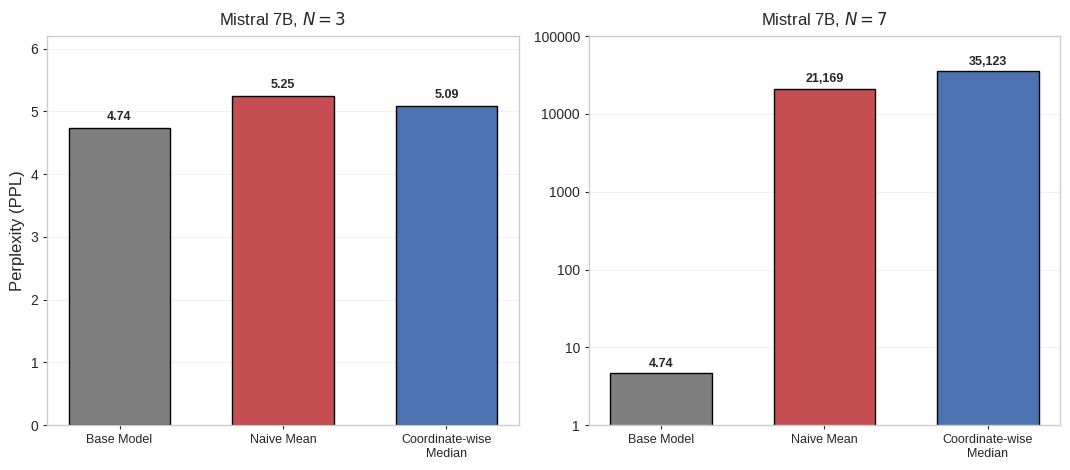

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.ticker import ScalarFormatter

def generate_paper_plot_mistral_combined(
    output_dir=".",
    filename_base="mistral_combined_ablation",
    show_suptitle=False
):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.8))

    labels = ["Base Model", "Naive Mean", "Coordinate-wise\nMedian"]
    n3_values = [4.7377, 5.2512, 5.0920]
    n7_values = [4.7377, 21169.44, 35123.08]

    colors = ["#7f7f7f", "#c44e52", "#4c72b0"]
    edgecolor = "black"
    linewidth = 1.0
    bar_width = 0.62

    def apply_common_style(ax):
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)
        ax.tick_params(axis="x", labelsize=9, length=3)
        ax.tick_params(axis="y", labelsize=10, length=3)
        ax.grid(axis="x", visible=False)
        ax.grid(axis="y", which="major", linestyle="-", alpha=0.25)
        ax.set_axisbelow(True)

    # Left panel: N=3
    ax1 = axes[0]
    x1 = np.arange(len(labels))
    bars1 = ax1.bar(
        x1, n3_values, color=colors, edgecolor=edgecolor,
        linewidth=linewidth, width=bar_width
    )

    ax1.set_xticks(x1)
    ax1.set_xticklabels(labels)
    ax1.set_title(r"Mistral 7B, $N=3$", fontsize=12, pad=8)
    ax1.set_ylabel("Perplexity (PPL)", fontsize=12)
    ax1.set_ylim(0, 6.2)
    apply_common_style(ax1)

    for bar in bars1:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2, h + 0.08,
            f"{h:.2f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    # Right panel: N=7
    ax2 = axes[1]
    x2 = np.arange(len(labels))
    bars2 = ax2.bar(
        x2, n7_values, color=colors, edgecolor=edgecolor,
        linewidth=linewidth, width=bar_width
    )

    ax2.set_xticks(x2)
    ax2.set_xticklabels(labels)
    ax2.set_title(r"Mistral 7B, $N=7$", fontsize=12, pad=8)
    ax2.set_yscale("log")
    ax2.set_ylim(1, 100000)
    ax2.set_yticks([1, 10, 100, 1000, 10000, 100000])

    sf = ScalarFormatter()
    sf.set_scientific(False)
    ax2.yaxis.set_major_formatter(sf)

    apply_common_style(ax2)
    ax2.grid(axis="y", which="minor", visible=False)

    for bar in bars2:
        h = bar.get_height()
        y_text = h * 1.10 if h >= 1000 else h * 1.08
        label = f"{h:,.0f}" if h >= 1000 else f"{h:.2f}"
        ax2.text(
            bar.get_x() + bar.get_width()/2, y_text,
            label,
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    if show_suptitle:
        fig.suptitle("Mistral 7B under Mild and Extreme Heterogeneity", fontsize=14, y=1.02)

    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)

    pdf_path = os.path.join(output_dir, f"{filename_base}.pdf")
    png_path = os.path.join(output_dir, f"{filename_base}.png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")

    print(f"[Saved] PDF: {pdf_path}")
    print(f"[Saved] PNG: {png_path}")

    plt.show()


if __name__ == "__main__":
    generate_paper_plot_mistral_combined(
        output_dir=".",
        filename_base="mistral_combined_ablation",
        show_suptitle=False
    )